In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

# 1. Load Dataset

In [182]:
file_path = "../datasets/phase_1/paysim-dataset.parquet"
df_clean = pd.read_parquet(file_path)
df_clean.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,-0.332937,1.452975,-0.140722,0,-0.969372,0.00000,1,0,False,False,False,True,False
1,1,-0.373767,0.065605,-0.140722,0,-0.183663,0.00000,1,0,False,False,False,True,False
2,1,-0.382384,-0.130713,-0.140722,1,-0.017832,0.00000,0,1,False,False,False,False,True
3,1,-0.382384,-0.130713,-0.118260,1,-0.017832,-0.14206,0,1,False,True,False,False,False
4,1,-0.323576,0.254812,-0.140722,0,-1.149510,0.00000,1,0,False,False,False,True,False


In [183]:
X_clean = df_clean.drop(columns=['isFraud'], errors='ignore')

# 2. Elbow Method

This section determines the optimal number of clusters (K) for K-Means clustering.

Two validation techniques are used:
- Elbow Method
- Approximate Silhouette Score

In [184]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [185]:
X_clean = X_clean.astype(np.float64)
def approximate_silhoutte_score(X, labels, centroids):
    distances = cdist(X, centroids, metric='euclidean')
    # a(i): distance to centroid of the cluster (intra)
    a = distances[np.arange(len(labels)), labels]

    # b(i): distance centroid to nearest centroid, except the self cluster
    temp = distances.copy()
    temp[np.arange(len(labels)), labels] = np.inf
    b = temp.min(axis=1)

    # Approximate silhoutte
    s = (b-a)/np.maximum(a, b)
    return np.mean(s)

An approximate silhouette score is used to efficiently evaluate cluster quality on the 6.3 million-record dataset without the high computational cost of the standard silhouette score.

In [ ]:
wcss = []
silhouette_scores = []

for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clean)
    wcss.append(kmeans.inertia_)
    
    score = approximate_silhoutte_score(
        X_clean,
        labels,
        kmeans.cluster_centers_
    )
    silhouette_scores.append(score)
    
    print(f"K={i} finished | WCSS: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Elbow Method (WCSS)
ax1.plot(range(2, 8), wcss, marker='o', color='blue')
ax1.set_title('Elbow Method (WCSS)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Silhouette Score
ax2.plot(range(2, 8), silhouette_scores, marker='s', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

K=2 finished | WCSS: 54110924152.65 | Silhouette Score: 0.6532
K=3 finished | WCSS: 33004227324.82 | Silhouette Score: 0.6605


Both the Elbow Method and the Approximate Silhouette Score indicate that K = 4 is the optimal number of clusters. At K = 4, the WCSS shows a clear elbow while the Approximate Silhouette Score reaches its highest value (0.6869), indicating compact and well-separated clusters. Therefore, K = 4 is selected for the subsequent K-Means clustering analysis.

# 3. KMeans Clustering

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_clean)
# df_sample['cluster_kmeans'] = df_clean.loc[df_sample.index, 'cluster_kmeans']

K-Means clustering is applied using the optimal number of clusters (K = 4) obtained from the Elbow Method and Approximate Silhouette Score.

# 4. Dimentional Reduction

PCA is applied to reduce the feature dimensions while preserving 95% of the data variance, improving the efficiency of HDBSCAN clustering.

In [ ]:
X_cluster = X_clean.drop(columns=['step'])

In [ ]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_cluster)

print(X_reduced.shape)

(6362604, 3)


PCA initially reduced the dataset using a 95% variance threshold. Two principal components were retained to preserve the data structure while improving the efficiency of HDBSCAN clustering

In [ ]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.74880332 0.19850196 0.03785987]
0.9851651400162024


The first two principal components retain approximately 98.8% of the total variance, indicating that most of the original information is preserved

In [ ]:
# pca = PCA(n_components=2)
# X_reduced = pca.fit_transform(X_clean)

# print(X_reduced.shape)

(6362604, 2)


Then, two principal components are selected for the subsequent HDBSCAN clustering based on the variance retained in the previous analysis

# 5. HDBSCAN Outlier Detection

In [ ]:
import gc
import hdbscan

# Random sampling to train HDBSCAN
np.random.seed(42)
sample_size = 100000
sample_indices = np.random.choice(
    len(X_reduced),
    size=sample_size,
    replace=False
)
X_reduced_sample = X_reduced[sample_indices]

# Train HDBSCAN
hdbscan_cpu = hdbscan.HDBSCAN(
    min_cluster_size=1000,
    min_samples=50,
    prediction_data=True,
    core_dist_n_jobs=-1
)
hdbscan_cpu.fit(X_reduced_sample)

# Predict by batching
batch_size = 500000
all_labels = []
for start in range(0, len(X_reduced), batch_size):

    X_batch = X_reduced[start:start + batch_size]

    labels, _ = hdbscan.approximate_predict(
        hdbscan_cpu,
        X_batch
    )

    all_labels.extend(labels)
df_clean["cluster_hdbscan"] = all_labels

outlier_count = (df_clean["cluster_hdbscan"] == -1).sum()

print(f"Outlier count: {outlier_count}")
print(f"Number of clusters: {df_clean['cluster_hdbscan'].nunique()-1}")

# Clean RAM
del X_reduced_sample
del hdbscan_cpu
del all_labels
del X_batch
del labels

gc.collect()

KeyboardInterrupt: 

HDBSCAN identified 59,418 observations as outliers with label -1, representing transactions with unusual patterns that may require further fraud investigation

# 6. Hierarchical Cluster

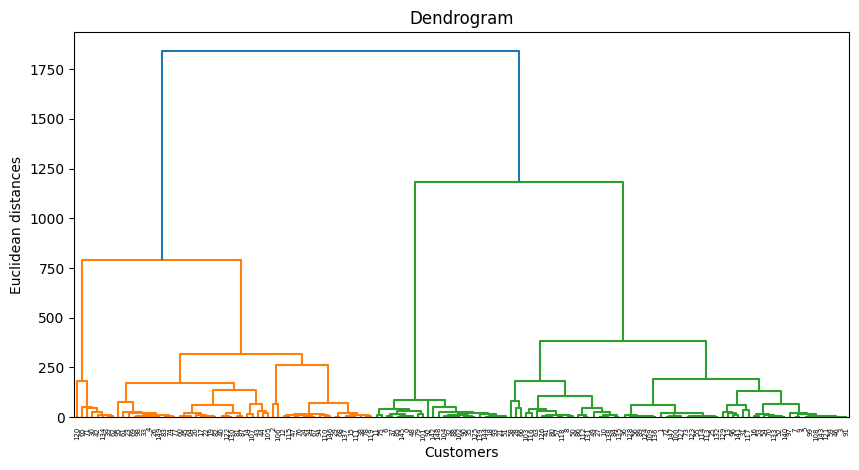

In [ ]:
import scipy.cluster.hierarchy as sch 

df_dendro = df_clean.sample(150, random_state=42)
plt.figure(figsize=(10, 5))
plt.title('Dendrogram')
dendrogram = sch.dendrogram(sch.linkage(df_dendro.drop(columns=['cluster_kmeans', 'cluster_hdbscan', 'isFraud'], errors='ignore'), method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

BIRCH is used as the hierarchical clustering algorithm because it efficiently builds a CF Tree, making it suitable for clustering the 6.3 million-record PaySim dataset.

In [ ]:
step = max(1, len(X_clean) // 100000)

X_birch_tune = X_clean.iloc[::step].copy()
X_birch_tune = X_birch_tune.astype(np.float32)

A representative subset is created to efficiently evaluate different BIRCH threshold values before training the final model on the complete dataset

In [ ]:
from sklearn.cluster import Birch
import pandas as pd
import time

thresholds = [8, 12, 16, 20, 24, 32]

results = []

for t in thresholds:
    print(f"Testing threshold = {t}")
    start = time.time()

    birch = Birch(
        threshold=t,
        branching_factor=50,
        n_clusters=None
    )
    birch.fit(X_birch_tune)
    elapsed = time.time() - start
    n_subclusters = len(birch.subcluster_centers_)

    results.append({
        "Threshold": t,
        "Subclusters": n_subclusters,
        "Time (sec)": round(elapsed, 2)
    })

    results_df = pd.DataFrame(results)

display(results_df)

Testing threshold = 8
Testing threshold = 12
Testing threshold = 16
Testing threshold = 20
Testing threshold = 24
Testing threshold = 32


,Threshold,Subclusters,Time (sec)
0,8,1772,10.82
1,12,807,7.63
2,16,432,6.50
3,20,257,5.75
4,24,135,4.81
5,32,73,3.50


Threshold 16 is selected because it produces an appropriate number of subclusters while maintaining efficient execution time for the subsequent clustering process

In [ ]:
from sklearn.cluster import Birch 

birch = Birch(
    threshold=16,
    branching_factor=50,
    n_clusters=None
)

birch.fit(X_clean)
print("Subclusters:", len(birch.subcluster_centers_))

Subclusters: 2317


The final BIRCH model generated 725 subclusters from the complete dataset, providing a hierarchical representation before forming the final clusters

In [ ]:
from sklearn.cluster import MiniBatchKMeans

subcluster_centers = birch.subcluster_centers_

mbk = MiniBatchKMeans(
    n_clusters=4,
    random_state=42,
    batch_size=128
)

mbk.fit(subcluster_centers)
print(mbk.cluster_centers_)

subcluster_to_cluster = mbk.labels_
print(subcluster_to_cluster.shape)

[[ 1.14247414e+02  3.44390134e+00  1.12003176e+02  3.04834097e+00
  -1.43329763e+01  1.03300778e+01  9.99515642e-03  1.78192765e-01
   7.52346339e-01  1.25366275e-01  6.46137795e-04  9.99515642e-03
   1.11646092e-01]
 [ 3.90677519e+02  3.78883577e+01  9.76099063e+01  3.37757408e-01
  -7.36481965e+02  2.16791484e+01  0.00000000e+00  8.03918919e-01
   0.00000000e+00  4.44144144e-01  0.00000000e+00  0.00000000e+00
   5.55855856e-01]
 [ 3.32427910e+02  3.29514079e+01  4.64964084e+01  5.11475988e+01
   6.05928751e-02  7.23091375e+01  3.83402567e-03  2.27280296e-01
   4.80752130e-01  1.10382825e-01  1.65939570e-03  3.83402567e-03
   4.03371623e-01]
 [ 5.88730176e+02  7.05043561e+00  3.49630444e+01  2.77548300e+01
  -5.06789387e+01  6.09671765e+00  1.23805912e-02  3.92106141e-01
   4.59769827e-01  2.39805141e-01  7.23736309e-03  1.23805912e-02
   2.80807078e-01]]
(2317,)


MiniBatchKMeans groups the 725 BIRCH subclusters into four final clusters for consistency with the selected K value. Each of the 725 BIRCH subclusters is assigned to one of the four final clusters

In [ ]:
subcluster_labels = birch.predict(X_clean)
final_labels = subcluster_to_cluster[subcluster_labels]
df_clean['cluster_birch'] = final_labels

Each transaction is assigned to its corresponding final cluster, enabling cluster profiling and comparison with K-Means and HDBSCAN

# 7. Profiling Cluster

In [ ]:
# cluster_profiles = df_clean.groupby('cluster_kmeans').mean()
# print("Cluster Profile (Mean):")
# print(cluster_profiles)

def cluster_summary(df, cluster_col, target_col="isFraud"):
    print(f"Cluster Summary: {cluster_col}")

    # Data freq each cluster
    cluster_size = (
        df[cluster_col]
        .value_counts()
        .sort_index()
        .rename("Total")
    )
    print("\nCluster Size")
    display(cluster_size)

    # Fraud statitics
    fraud_rate = (
        df.groupby(cluster_col)[target_col]
        .agg(
            Fraud_Rate="mean",
            Fraud_Count="sum",
            Total="count"
        )
    )

    fraud_rate['Fraud_Rate'] *= 100

    print("\nFraud Statistics")
    display(fraud_rate.round(2))

    # Numerical profile
    cluster_profile = (
        df.groupby(cluster_col)
        .mean(numeric_only=True)
        .round(2)
    )

    print("\nCluster Profile")
    display(cluster_profile)

    return cluster_profile, fraud_rate



This function summarizes the clustering results by reporting the number of records in each cluster, the fraud statistics, and the average values of numerical features. These summaries are used to compare cluster characteristics and support business interpretation of the transaction segments

In [ ]:
# KMeans Profile
profile_kmeans, fraud_kmeans = cluster_summary(
    df_clean,
    "cluster_kmeans"
)

# HDBSCAN Profile
profile_hdbscan, fraud_hdbscan = cluster_summary(
    df_clean,
    "cluster_hdbscan"
)

# BIRCH Profile
profile_birch, fraud_birch = cluster_summary(
    df_clean,
    "cluster_birch"
)

Cluster Summary: cluster_kmeans

Cluster Size


cluster_kmeans
0    2551323
1    2409349
2    1059646
3     342286
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_kmeans,,,
0,0.07,1695,2551323
1,0.09,2158,2409349
2,0.12,1320,1059646
3,0.88,3024,342286



Cluster Profile


...

cluster_birch
0    2825824
1        892
2    3182495
3     353393
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_birch,,,
0,0.08,2330,2825824
1,99.89,891,892
2,0.06,1934,3182495
3,0.86,3042,353393



Cluster Profile


,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan
cluster_birch,,,,,,,,,,,,,,,,
0,117.92,0.41,8.84,0.92,0.00,2.26,0.70,0.33,0.23,0.23,0.35,0.01,0.33,0.08,0.75,6.36
1,389.53,38.35,85.69,0.31,1.00,-745.29,25.49,0.00,0.84,0.00,0.50,0.00,0.00,0.50,1.63,-0.90
2,317.61,0.64,6.74,1.11,0.00,2.18,0.97,0.34,0.24,0.21,0.35,0.01,0.34,0.08,0.75,9.14
3,578.04,0.46,5.90,1.10,0.01,1.77,0.60,0.35,0.26,0.23,0.32,0.01,0.35,0.09,2.94,2.50


K-Means successfully segmented the transactions into four clusters with relatively balanced sizes. Clusters 0, 1, and 2 represent normal transaction behaviors with fraud rates below 0.12%, while Cluster 3 exhibits the highest fraud rate (0.88%) and larger transaction values, indicating a higher-risk transaction group. These results show that K-Means is effective for identifying broad behavioral segments within the dataset

Unlike K-Means, HDBSCAN automatically identified 26 dense clusters together with one outlier group (label -1). The outlier cluster has the highest fraud rate (2.82%), while several dense clusters such as Cluster 0, Cluster 4, and Cluster 14 also show relatively elevated fraud rates. This indicates that HDBSCAN is effective in separating normal transaction patterns from anomalous behaviors without requiring a predefined number of clusters

BIRCH produced four hierarchical clusters with one dominant normal transaction group and one medium-sized higher-risk group. In addition, it isolated a very small cluster containing only 892 transactions with a fraud rate of 99.89%, demonstrating its ability to separate highly anomalous transaction patterns. These results suggest that BIRCH is effective for hierarchical segmentation while highlighting rare but suspicious transaction behaviors

The three clustering algorithms complement each other in analyzing transaction behavior. K-Means provides broad behavioral segmentation, HDBSCAN is effective for detecting outliers and irregular transaction patterns, and BIRCH efficiently performs hierarchical segmentation on a very large dataset while isolating highly suspicious groups. Using these methods together offers a more comprehensive view of transaction behavior and supports fraud detection from different analytical perspectives

# 8. Cluster Visualization

In [ ]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_clean)

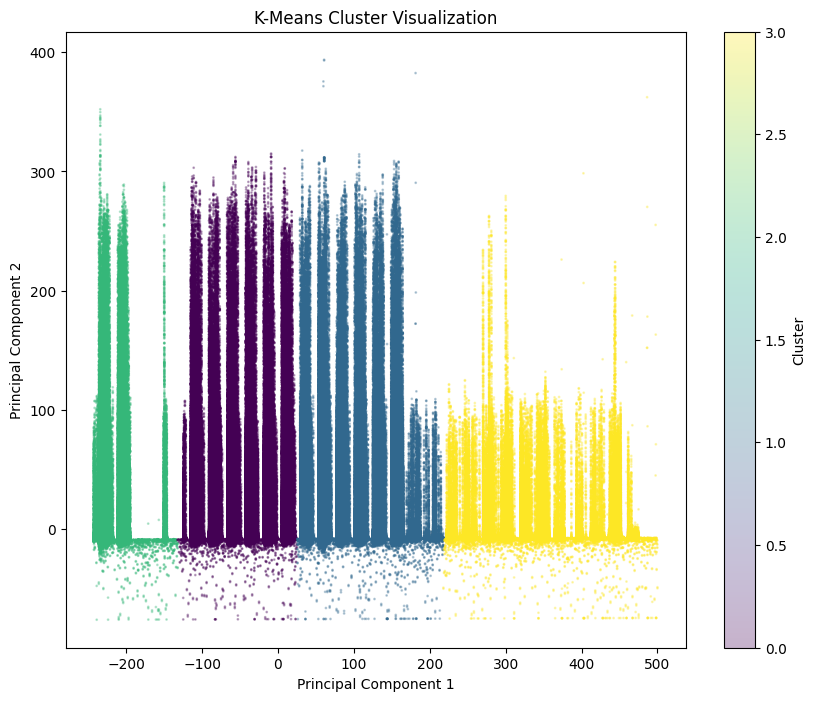

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=df_clean["cluster_kmeans"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("K-Means Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

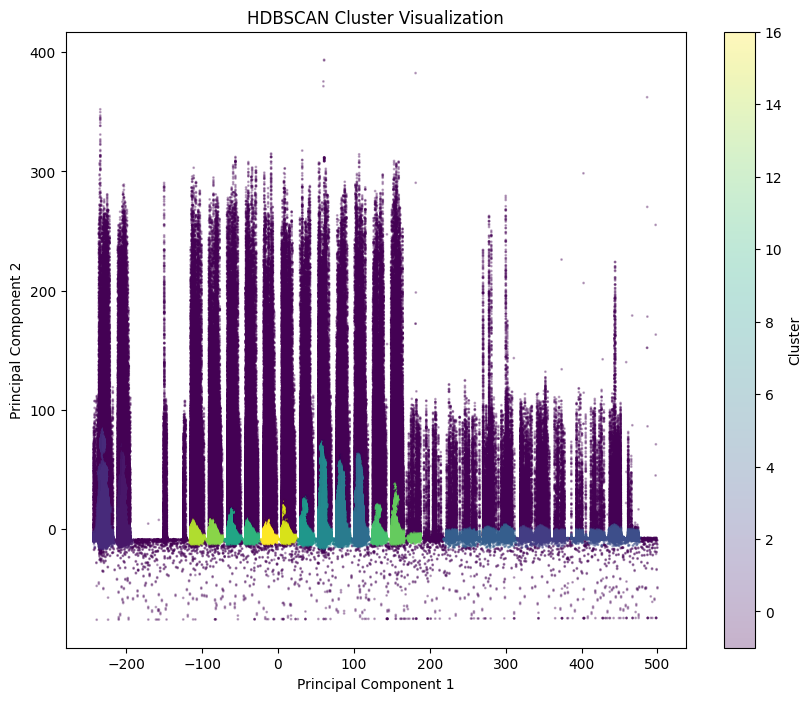

In [ ]:
# HDBSCAN Visualization
plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df_clean["cluster_hdbscan"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("HDBSCAN Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

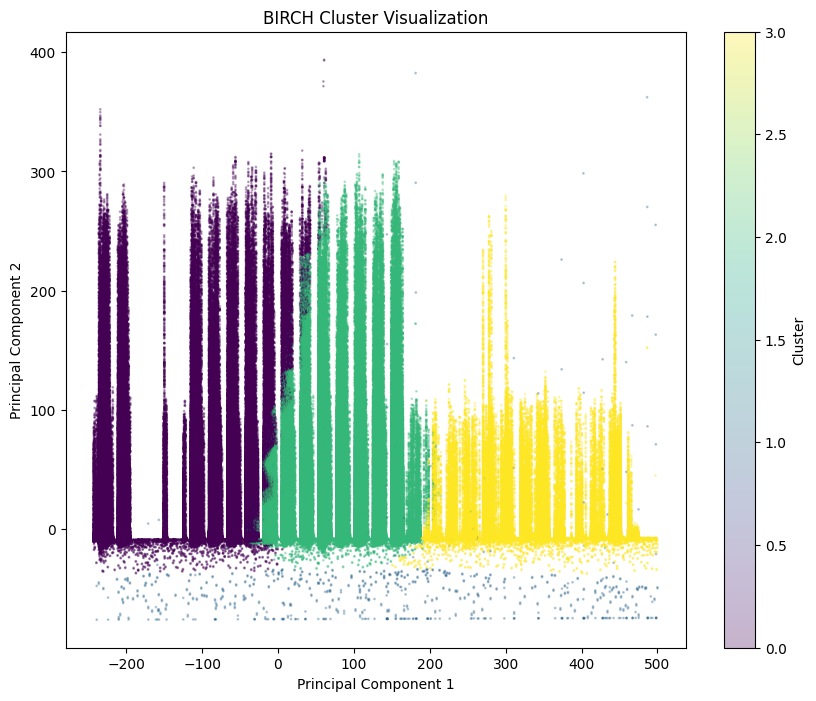

In [ ]:
# BIRCH Visualization
plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df_clean["cluster_birch"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("BIRCH Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Export

In [ ]:
folder_path = "../datasets/phase_2"

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

df_clean.to_parquet(os.path.join(folder_path, 'paysim-dataset-phase2.parquet'), index=False)

# Outliers for phase 4
df_outliers = df_clean[df_clean['cluster_hdbscan'] == -1].copy()
df_outliers.to_parquet(os.path.join(folder_path, 'paysim-outliers-phase4.parquet'), index=False)

# Profile cluster
cluster_profiles.to_csv(os.path.join(folder_path, 'cluster-summary-phase2.csv'))

del df_outliers, cluster_profiles
gc.collect()

NameError: name 'cluster_profiles' is not defined